<a href="https://colab.research.google.com/github/chandradharvasireddy-19/25BDS0329/blob/main/exp6_18.08.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
df=pd.read_csv("/content/WineQT.csv")
print(df.head(3))
print(df.tail(3))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [3]:
#Check data types of each column
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [4]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

In [5]:
pd.isna(df).any()

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [8]:
#numeric values
df['citric acid'].astype(str).str.isnumeric().value_counts()

,count
citric acid,
False,1143


In [10]:
df['citric acid'].loc[df['citric acid'].astype(str).str.isnumeric() == False]

,citric acid
0,0.00
1,0.00
2,0.04
3,0.56
4,0.00
...,...
1138,0.13
1139,0.08
1140,0.08
1141,0.10


In [11]:
df.loc[[5, 12, 25], 'alcohol'] = '?'
df.loc[[10, 34, 52], 'fixed acidity'] = '?'

/tmp/ipykernel_727/2237813058.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[[5, 12, 25], 'alcohol'] = '?'
/tmp/ipykernel_727/2237813058.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[[10, 34, 52], 'fixed acidity'] = '?'


In [14]:
alcohol_clean = df['alcohol'].loc[df['alcohol'] != '?']
print(alcohol_clean.head(20))

0      9.4
1      9.8
2      9.8
3      9.8
4      9.4
6      9.4
7     10.0
8      9.5
9      9.2
10     9.9
11     9.1
13     9.2
14     9.7
15     9.5
16     9.4
17     9.7
18     9.3
19     9.5
20     9.4
21     9.8
Name: alcohol, dtype: object


In [16]:
amean = alcohol_clean.astype(float).mean()
print("mean=",amean)

mean= 10.443713450292396


In [17]:
df['alcohol'] = df['alcohol'].replace('?', amean).astype(float).astype(int)
print(df['alcohol'].head(10))

0     9
1     9
2     9
3     9
4     9
5    10
6     9
7    10
8     9
9     9
Name: alcohol, dtype: int64


/tmp/ipykernel_727/2601347028.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['alcohol'] = df['alcohol'].replace('?', amean).astype(float).astype(int)


In [18]:
# Cleaning the fixed acidity field
fixed_acidity = df['fixed acidity'].loc[df['fixed acidity'] != '?']
famean = fixed_acidity.astype(float).astype(int).mean()
df['fixed acidity'] = df['fixed acidity'].replace('?', famean).astype(float).astype(int)
df['fixed acidity'].head()


/tmp/ipykernel_727/1351855095.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fixed acidity'] = df['fixed acidity'].replace('?', famean).astype(float).astype(int)


,fixed acidity
0,7
1,7
2,7
3,11
4,7


In [20]:
## Cleaning the Normalized losses field
print(df[df['residual sugar'] == '?'].count())
nl = df['residual sugar'].loc[df['residual sugar'] != '?'].count()
nmean = nl.astype(int).mean()
df['residual sugar'] = df['residual sugar'].replace('?', nmean).astype(float).astype(int)
df['residual sugar'].head()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


,residual sugar
0,1
1,2
2,2
3,1
4,1


In [21]:
#central tendency of density column
#1.Descriptive Statistics
mean = df["density"].mean()
median =df["density"].median()
mode = df["density"].mode()
print(mean , median, mode)


0.9967304111986001 0.99668 0    0.9976
Name: density, dtype: float64


/tmp/ipykernel_727/3308633123.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="quality", y="alcohol", data=df, ci=None, palette="muted", edgecolor='blue')
/tmp/ipykernel_727/3308633123.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="quality", y="alcohol", data=df, ci=None, palette="muted", edgecolor='blue')


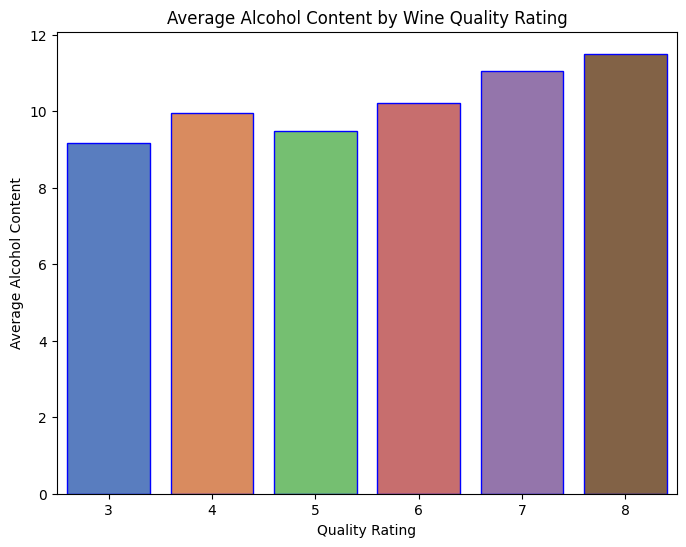

In [23]:
#2.Visualisation
#Barplot alc vs quality
df['alcohol'] = df['alcohol'].astype(float)
df['quality'] = df['quality'].astype(int)
plt.figure(figsize=(8, 6))
sns.barplot(x="quality", y="alcohol", data=df, ci=None, palette="muted", edgecolor='blue')
plt.title("Average Alcohol Content by Wine Quality")
plt.ylabel('Average Alcohol Content')
plt.xlabel('Quality Rating')
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


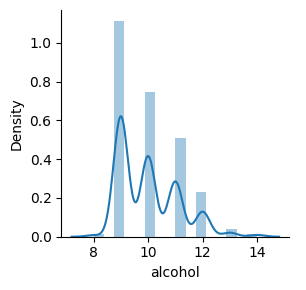

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


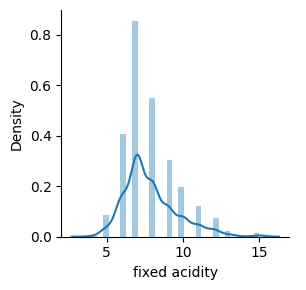

In [24]:
# distribution plot
sns.FacetGrid(df).map(sns.distplot, "alcohol").add_legend()
plt.show()
sns.FacetGrid(df).map(sns.distplot, "fixed acidity").add_legend()
plt.show()

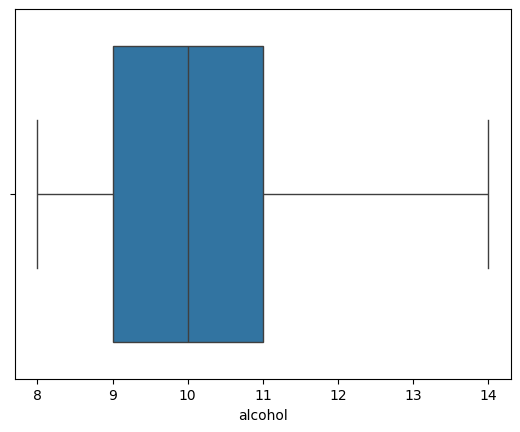

In [25]:
# boxplot for alcohol content
sns.boxplot(x="alcohol", data=df)
plt.show()


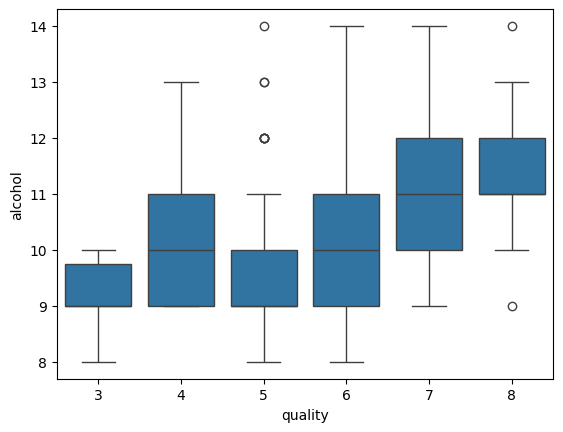

In [26]:
# boxplot to visualize the distribution of "alcohol" across types of wine "quality"
sns.boxplot(x="quality", y="alcohol", data=df)
plt.show()


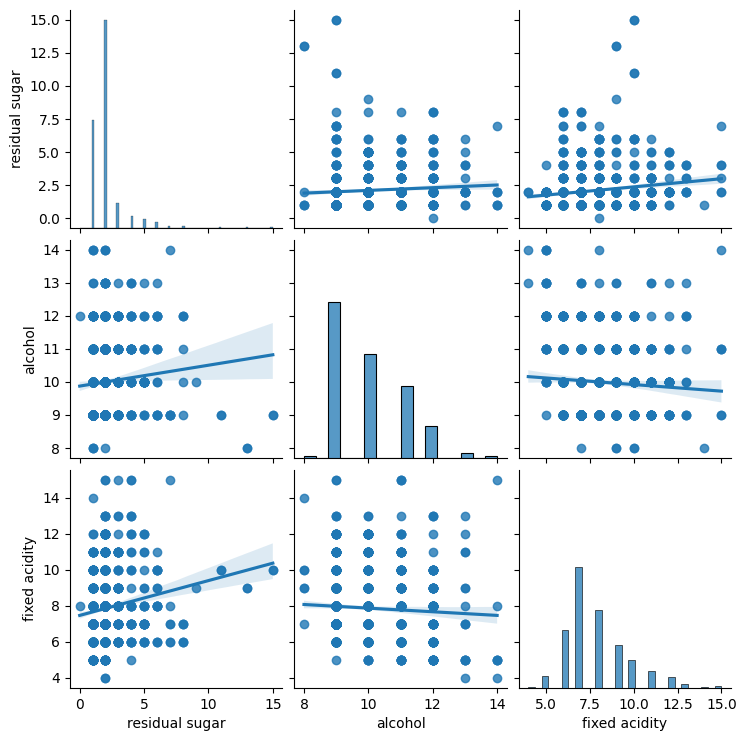

In [27]:
# pair plot with plot type regression
sns.pairplot(df, vars=['residual sugar', 'alcohol', 'fixed acidity'], kind="reg")
plt.show()


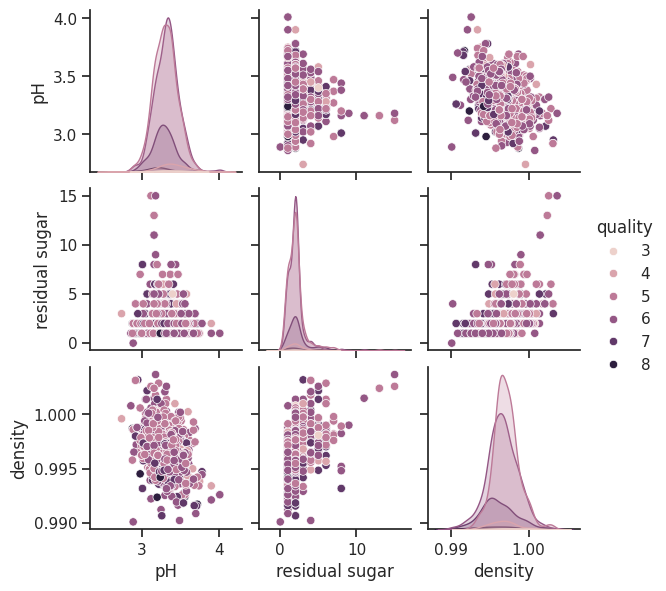

In [28]:
# pair plot (matrix scatterplot) of selected numerical columns colored by quality
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['pH', 'residual sugar', 'density'], hue="quality")
plt.show()


In [31]:
corr = stats.pearsonr(df["alcohol"], df["fixed acidity"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

p-value:	 0.011139877483290973
cor:		 -0.0750548531798282


In [32]:
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.275826         -0.007892    -0.139011   

                   

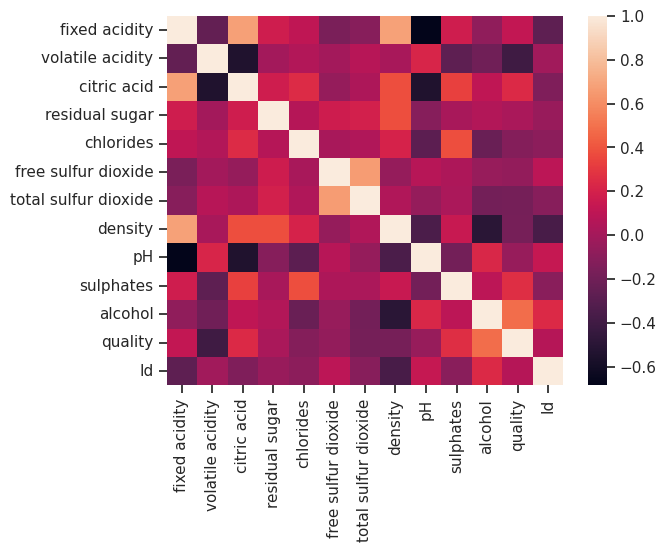

In [33]:
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns)
plt.show()